In [2]:
import xarray as xr
ds = xr.open_dataset(
    r"D:\my project\Climate Modelling\data\raw\ERA5_t2m_1990_2024_punjab.nc"
)
ds

<xarray.Dataset> Size: 1MB
Dimensions:     (valid_time: 437, latitude: 29, longitude: 25)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 3kB 1990-01-01 ... 2026-05-01
    expver      (valid_time) <U4 7kB ...
  * latitude    (latitude) float64 232B 35.0 34.75 34.5 ... 28.5 28.25 28.0
  * longitude   (longitude) float64 200B 72.0 72.25 72.5 ... 77.5 77.75 78.0
    number      int64 8B ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 1MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-06-09T17:43 GRIB to CDM+CF via cfgrib-0.9.1...

In [3]:
ds.dims

FrozenMappingWarningOnValuesAccess({'valid_time': 437, 'latitude': 29, 'longitude': 25})

In [4]:
ds.t2m.shape

(437, 29, 25)

In [5]:
ds.valid_time.max()

<xarray.DataArray 'valid_time' ()> Size: 8B
array('2026-05-01T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    number   int64 8B ...
Attributes:
    long_name:      time
    standard_name:  time

In [6]:
ds.valid_time.min().values

np.datetime64('1990-01-01T00:00:00.000000000')

In [7]:
print(ds.t2m.shape)
print(ds.valid_time.min().values)
print(ds.valid_time.max().values)

(437, 29, 25)
1990-01-01T00:00:00.000000000
2026-05-01T00:00:00.000000000


In [8]:
t2m_c = ds.t2m -273.15

In [9]:
#mean time series
punjab_ts = t2m_c.mean(
    dim=["latitude","longitude"]
)

punjab_ts

<xarray.DataArray 't2m' (valid_time: 437)> Size: 2kB
array([ 7.108258 ,  7.5066495, 10.74118  , 17.715216 , 23.6053   ,
       25.999878 , 24.988216 , 24.411266 , 22.7691   , 16.450716 ,
       11.478238 ,  6.3214855,  3.9694443,  7.3537655, 12.347552 ,
       16.480846 , 21.904303 , 24.655945 , 25.949879 , 24.440392 ,
       22.656853 , 16.266191 , 10.8198805,  6.733712 ,  5.743708 ,
        6.191514 , 11.737003 , 17.14191  , 21.352982 , 25.196312 ,
       24.294544 , 24.055988 , 21.16314  , 16.91056  , 11.167488 ,
        7.1927204,  3.9995189,  9.369543 , 10.627577 , 18.262634 ,
       23.780592 , 25.544992 , 24.090254 , 25.477953 , 22.193491 ,
       17.284372 , 11.437029 ,  6.4359245,  5.8293786,  6.8622117,
       13.886401 , 16.613518 , 22.950932 , 25.891983 , 24.727823 ,
       24.33105  , 21.747545 , 16.567202 , 11.556059 ,  6.433377 ,
        3.6023204,  7.5908546, 11.816964 , 17.100441 , 23.415186 ,
       26.40184  , 25.082441 , 23.452974 , 22.30171  , 17.262432 ,
       10.623158 ,  5.841348 ,  4.5407043,  8.110158 , 13.684301 ,
       18.490582 , 21.828596 , 23.776144 , 24.974628 , 23.660194 ,
       22.653683 , 15.88796  ,  9.953226 ,  5.4063582,  4.0421567,
        6.721875 , 12.069647 , 16.668217 , 20.389875 , 23.949839 ,
       25.837013 , 23.896244 , 23.032633 , 14.94566  ,  9.55155  ,
        4.7357903,  4.5807524,  7.782578 , 11.32287  , 19.028502 ,
...
       23.239325 , 25.57052  , 25.30722  , 25.520824 , 22.460493 ,
       16.473734 , 11.139918 ,  5.421287 ,  4.72799  ,  7.2364626,
       11.790563 , 19.790844 , 22.301376 , 25.464584 , 25.2998   ,
       24.935461 , 24.256624 , 17.732077 , 11.384159 ,  3.9868824,
        4.3102093,  8.203103 , 11.864277 , 17.895779 , 22.507586 ,
       25.23937  , 25.94707  , 25.650118 , 24.019226 , 18.657711 ,
       10.597377 ,  5.603633 ,  4.6662183, 10.042398 , 14.779914 ,
       17.876572 , 22.005049 , 25.056194 , 25.959011 , 25.449345 ,
       23.408346 , 18.21395  , 10.500185 ,  5.7355995,  5.0509152,
        7.854864 , 16.302893 , 22.34993  , 24.884089 , 26.042604 ,
       25.27111  , 25.02288  , 23.52547  , 17.714663 , 11.174124 ,
        6.2509017,  4.308712 , 10.505903 , 13.800349 , 17.735975 ,
       20.567373 , 24.38513  , 24.805038 , 25.908503 , 24.037094 ,
       17.60876  , 12.195593 ,  7.16769  ,  4.175745 ,  7.52882  ,
       13.20859  , 18.038774 , 24.557468 , 26.726986 , 27.021734 ,
       24.95347  , 24.018414 , 20.14689  , 13.358278 ,  5.813576 ,
        5.656285 ,  9.15873  , 13.676621 , 20.915264 , 23.938356 ,
       26.26375  , 25.444788 , 24.624672 , 23.50147  , 17.083088 ,
       10.600175 ,  7.9684777,  4.625612 , 10.230525 , 15.530251 ,
       18.949774 , 23.504913 ], dtype=float32)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 3kB 1990-01-01 ... 2026-05-01
    expver      (valid_time) <U4 7kB ...
    number      int64 8B ...
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      725
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

In [10]:
punjab_ts.shape

(437,)

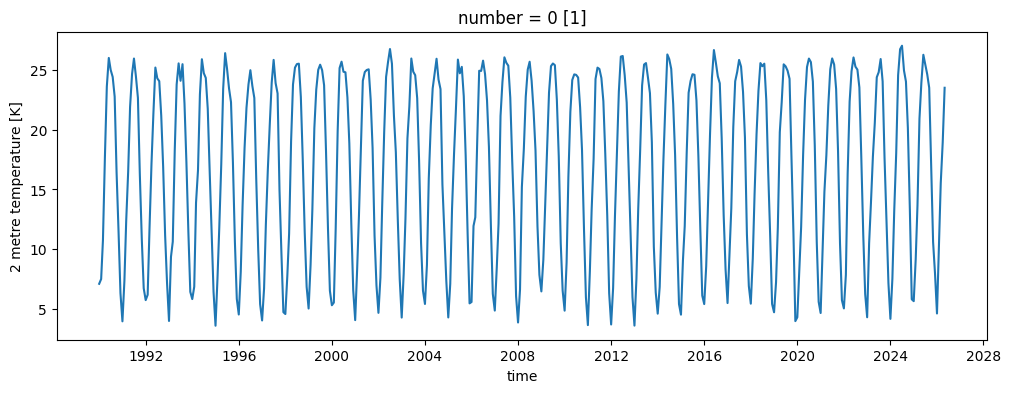

In [11]:
import matplotlib.pyplot as plt
punjab_ts.plot(figsize=(12,4))

plt.show()

In [12]:
#annual_mean
annual_ts = punjab_ts.groupby(
    "valid_time.year"
).mean()

annual_ts

<xarray.DataArray 't2m' (year: 37)> Size: 148B
array([16.591291, 16.131563, 16.012321, 16.54199 , 16.449791, 16.20764 ,
       16.080545, 15.486709, 16.766748, 17.182266, 16.937029, 16.816465,
       17.275267, 16.533987, 17.186823, 16.466856, 17.405565, 17.209988,
       16.770819, 17.039328, 17.23915 , 16.744596, 16.477762, 16.709036,
       16.387615, 16.500496, 17.741444, 17.448473, 17.001444, 16.575567,
       16.707956, 16.974398, 17.62037 , 16.918844, 17.462397, 17.40264 ,
       14.568214], dtype=float32)
Coordinates:
  * year     (year) int64 296B 1990 1991 1992 1993 1994 ... 2023 2024 2025 2026
    number   int64 8B ...
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      725
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

In [13]:
annual_ts.shape

(37,)

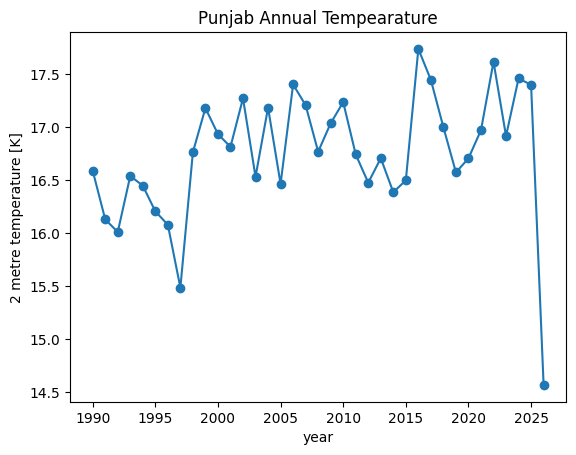

In [14]:
#plot annual teperature
annual_ts.plot(marker="o")
plt.title("Punjab Annual Tempearature")
plt.show()

In [15]:
print(ds.valid_time.min().values)
print(ds.valid_time.max().values)

punjab_ts.shape
annual_ts.shape

1990-01-01T00:00:00.000000000
2026-05-01T00:00:00.000000000


(37,)

In [16]:
year = annual_ts.year
year

<xarray.DataArray 'year' (year: 37)> Size: 296B
array([1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001,
       2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013,
       2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025,
       2026])
Coordinates:
  * year     (year) int64 296B 1990 1991 1992 1993 1994 ... 2023 2024 2025 2026
    number   int64 8B ...

In [17]:
import numpy as np

slope, intercept = np.polyfit(
    year,
    annual_ts.values,
    1
)

slope

np.float64(0.014679572547200027)

In [18]:
trend_line = slope*year+intercept

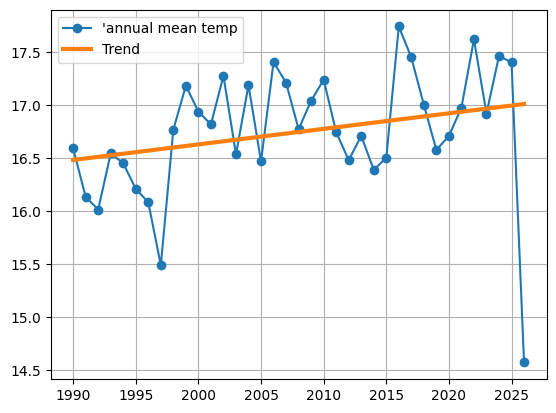

In [19]:
plt.Figure(figsize=(10,5))


plt.plot(year,annual_ts.values,marker="o",label="'annual mean temp")
plt.plot(year,trend_line,linewidth=3,label="Trend")

plt.legend()
plt.grid(True)
plt.show()


In [20]:
annual_ts = annual_ts.sel(year=slice(1990,2024))

In [21]:
print("Slope (°C/year):", slope)
print("Slope (°C/decade):", slope * 10)

Slope (°C/year): 0.014679572547200027
Slope (°C/decade): 0.14679572547200026


In [22]:
annual_ts_clean = annual_ts.sel(
    year=slice(1990, 2024)
)

annual_ts_clean.shape

(35,)

In [23]:
years = annual_ts_clean.year

slope,intercept = np.polyfit(
    years,
    annual_ts_clean.values,
    1
)
print("°C/year :", slope)
print("°C/decade :", slope * 10)

°C/year : 0.025615755716958906
°C/decade : 0.25615755716958905


In [24]:
annual_ts_clean = annual_ts.sel(year=slice(1990, 2024))
annual_ts_clean

<xarray.DataArray 't2m' (year: 35)> Size: 140B
array([16.591291, 16.131563, 16.012321, 16.54199 , 16.449791, 16.20764 ,
       16.080545, 15.486709, 16.766748, 17.182266, 16.937029, 16.816465,
       17.275267, 16.533987, 17.186823, 16.466856, 17.405565, 17.209988,
       16.770819, 17.039328, 17.23915 , 16.744596, 16.477762, 16.709036,
       16.387615, 16.500496, 17.741444, 17.448473, 17.001444, 16.575567,
       16.707956, 16.974398, 17.62037 , 16.918844, 17.462397],
      dtype=float32)
Coordinates:
  * year     (year) int64 280B 1990 1991 1992 1993 1994 ... 2021 2022 2023 2024
    number   int64 8B ...
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      725
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

In [25]:
print("Warmest year:", annual_ts_clean.idxmax().values)
print("Warmest temp:", annual_ts_clean.max().values)

print("Coldest year:", annual_ts_clean.idxmin().values)
print("Coldest temp:", annual_ts_clean.min().values)

Warmest year: 2016.0
Warmest temp: 17.741444
Coldest year: 1997.0
Coldest temp: 15.486709


In [26]:
years = annual_ts_clean.year

slope, intercept = np.polyfit(
    years,
    annual_ts_clean.values,
    1
)

print("°C/year :", slope)
print("°C/decade :", slope * 10)

°C/year : 0.025615755716958906
°C/decade : 0.25615755716958905


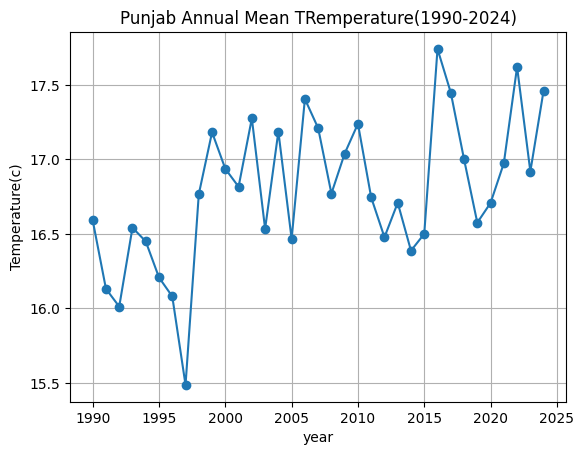

In [27]:
annual_ts_clean.plot(marker="o")

plt.title("Punjab Annual Mean TRemperature(1990-2024)")
plt.ylabel("Temperature(c)")
plt.grid(True)

plt.show()

In [28]:
climatology = annual_ts_clean.mean()

climatology

<xarray.DataArray 't2m' ()> Size: 4B
array(16.788645, dtype=float32)
Coordinates:
    number   int64 8B 0
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      725
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

In [29]:
anomaly = annual_ts_clean - climatology

anomaly

<xarray.DataArray 't2m' (year: 35)> Size: 140B
array([-0.19735336, -0.6570816 , -0.7763233 , -0.24665451, -0.33885384,
       -0.5810051 , -0.70809937, -1.3019361 , -0.02189636,  0.39362144,
        0.1483841 ,  0.02782059,  0.48662186, -0.25465775,  0.3981781 ,
       -0.3217888 ,  0.6169205 ,  0.42134285, -0.01782608,  0.25068283,
        0.4505043 , -0.04404831, -0.31088257, -0.07960892, -0.4010296 ,
       -0.28814888,  0.95279884,  0.6598282 ,  0.21279907, -0.21307755,
       -0.08068848,  0.18575287,  0.8317261 ,  0.13019943,  0.67375183],
      dtype=float32)
Coordinates:
  * year     (year) int64 280B 1990 1991 1992 1993 1994 ... 2021 2022 2023 2024
    number   int64 8B 0
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      725
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

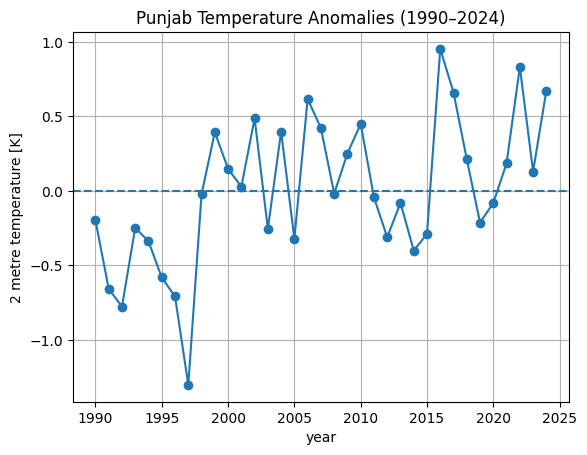

In [30]:
anomaly.plot(marker="o")
plt.axhline(0, linestyle="--")
plt.title("Punjab Temperature Anomalies (1990–2024)")
plt.grid(True)
plt.show()

In [31]:
climatology = annual_ts_clean.mean()
print(climatology.values)

anomaly = annual_ts_clean - climatology

print(anomaly.max().values)
print(anomaly.min().values)

16.788645
0.95279884
-1.3019361


In [32]:
anomaly = annual_ts_clean-climatology
anomaly

<xarray.DataArray 't2m' (year: 35)> Size: 140B
array([-0.19735336, -0.6570816 , -0.7763233 , -0.24665451, -0.33885384,
       -0.5810051 , -0.70809937, -1.3019361 , -0.02189636,  0.39362144,
        0.1483841 ,  0.02782059,  0.48662186, -0.25465775,  0.3981781 ,
       -0.3217888 ,  0.6169205 ,  0.42134285, -0.01782608,  0.25068283,
        0.4505043 , -0.04404831, -0.31088257, -0.07960892, -0.4010296 ,
       -0.28814888,  0.95279884,  0.6598282 ,  0.21279907, -0.21307755,
       -0.08068848,  0.18575287,  0.8317261 ,  0.13019943,  0.67375183],
      dtype=float32)
Coordinates:
  * year     (year) int64 280B 1990 1991 1992 1993 1994 ... 2021 2022 2023 2024
    number   int64 8B 0
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      725
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

In [33]:
anomaly.mean()

<xarray.DataArray 't2m' ()> Size: 4B
array(-7.901873e-07, dtype=float32)
Coordinates:
    number   int64 8B 0
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      725
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

In [34]:
anomaly.mean().values

array(-7.901873e-07, dtype=float32)

In [35]:
#largest +ve and -negative anomaly
print("Max anomaly",anomaly.max().values)
print("Min anomaly",anomaly.min().values)

print("Year:",anomaly.idxmax().values)
print("Year:",anomaly.idxmin().values)

Max anomaly 0.95279884
Min anomaly -1.3019361
Year: 2016.0
Year: 1997.0


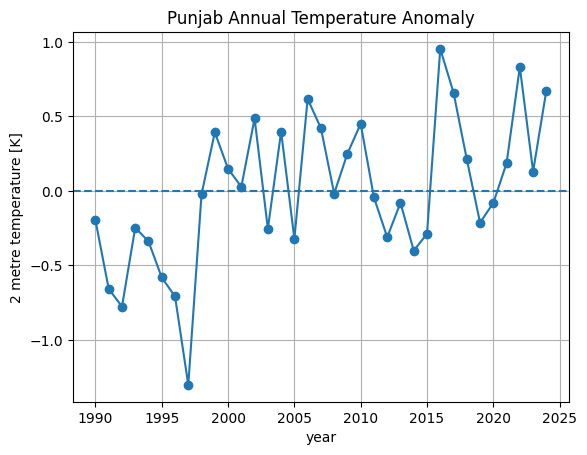

In [36]:
#plot anomaly
import matplotlib.pyplot as plt
anomaly.plot(marker="o")
plt.axhline(0,linestyle="--")
plt.title("Punjab Annual Temperature Anomaly")
plt.grid(True)
plt.show()

In [37]:
print(climatology.values)

print(anomaly.max().values)
print(anomaly.idxmax().values)

print(anomaly.min().values)
print(anomaly.idxmin().values)

16.788645
0.95279884
2016.0
-1.3019361
1997.0


In [38]:
#warm vs cool year a simple climate indicator
warm_years =(anomaly>0).sum()
cool_years =(anomaly<0).sum()

print("warm year:", warm_years)
print("cool_year:",cool_years)

warm year: <xarray.DataArray 't2m' ()> Size: 8B
array(16)
Coordinates:
    number   int64 8B 0
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      725
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0
cool_year: <xarray.DataArray 't2m' ()> Size: 8B
array(19)
Coordinates:
    number   int64 8B 0
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    

In [39]:
#check deccade
anomaly.sel(year=slice(1990,1999)).mean()

<xarray.DataArray 't2m' ()> Size: 4B
array(-0.44355822, dtype=float32)
Coordinates:
    number   int64 8B 0
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      725
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

In [40]:
anomaly.sel(year=slice(2000,2009)).mean()

<xarray.DataArray 't2m' ()> Size: 4B
array(0.17556782, dtype=float32)
Coordinates:
    number   int64 8B 0
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      725
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

In [41]:
anomaly.sel(year=slice(2020,2024)).mean()

<xarray.DataArray 't2m' ()> Size: 4B
array(0.34814835, dtype=float32)
Coordinates:
    number   int64 8B 0
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      725
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

In [42]:
warm_years = (anomaly > 0).sum()
cool_years = (anomaly < 0).sum()

print(warm_years.values)
print(cool_years.values)

16
19


In [43]:
print("1990s:", anomaly.sel(year=slice(1990,1999)).mean().values)

print("2000s:", anomaly.sel(year=slice(2000,2009)).mean().values)

print("2010s:", anomaly.sel(year=slice(2010,2019)).mean().values)

print("2020-2024:", anomaly.sel(year=slice(2020,2024)).mean().values)

1990s: -0.44355822
2000s: 0.17556782
2010s: 0.09391346
2020-2024: 0.34814835


Annual temperature anomalies over Punjab indicate a shift from predominantly cooler-than-average conditions during the 1990s (-0.44°C) to predominantly warmer-than-average conditions in recent decades. The highest mean anomaly occurred during 2020–2024 (+0.35°C), consistent with the long-term warming trend identified in the ERA5 temperature record.


In [44]:
anomaly.sortby(anomaly)

<xarray.DataArray 't2m' (year: 35)> Size: 140B
array([-1.3019361 , -0.7763233 , -0.70809937, -0.6570816 , -0.5810051 ,
       -0.4010296 , -0.33885384, -0.3217888 , -0.31088257, -0.28814888,
       -0.25465775, -0.24665451, -0.21307755, -0.19735336, -0.08068848,
       -0.07960892, -0.04404831, -0.02189636, -0.01782608,  0.02782059,
        0.13019943,  0.1483841 ,  0.18575287,  0.21279907,  0.25068283,
        0.39362144,  0.3981781 ,  0.42134285,  0.4505043 ,  0.48662186,
        0.6169205 ,  0.6598282 ,  0.67375183,  0.8317261 ,  0.95279884],
      dtype=float32)
Coordinates:
  * year     (year) int64 280B 1997 1992 1996 1991 1995 ... 2017 2024 2022 2016
    number   int64 8B 0
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      725
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

In [45]:
anomaly.to_series().sort_values().tail(5)

year
2006    0.616920
2017    0.659828
2024    0.673752
2022    0.831726
2016    0.952799
Name: t2m, dtype: float32

In [46]:
anomaly.to_series().sort_values(ascending=False).head(5)

year
2016    0.952799
2022    0.831726
2024    0.673752
2017    0.659828
2006    0.616920
Name: t2m, dtype: float32

In [47]:
anomaly.to_series().sort_values().tail(5)

year
2006    0.616920
2017    0.659828
2024    0.673752
2022    0.831726
2016    0.952799
Name: t2m, dtype: float32

In [48]:
extreme_warm = anomaly[anomaly>0.5]
extreme_warm

<xarray.DataArray 't2m' (year: 5)> Size: 20B
array([0.6169205 , 0.95279884, 0.6598282 , 0.8317261 , 0.67375183],
      dtype=float32)
Coordinates:
  * year     (year) int64 40B 2006 2016 2017 2022 2024
    number   int64 8B 0
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      725
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

In [49]:
len(extreme_warm)

5

In [50]:
extreme_cool = anomaly[anomaly<0.5]
extreme_cool

<xarray.DataArray 't2m' (year: 30)> Size: 120B
array([-0.19735336, -0.6570816 , -0.7763233 , -0.24665451, -0.33885384,
       -0.5810051 , -0.70809937, -1.3019361 , -0.02189636,  0.39362144,
        0.1483841 ,  0.02782059,  0.48662186, -0.25465775,  0.3981781 ,
       -0.3217888 ,  0.42134285, -0.01782608,  0.25068283,  0.4505043 ,
       -0.04404831, -0.31088257, -0.07960892, -0.4010296 , -0.28814888,
        0.21279907, -0.21307755, -0.08068848,  0.18575287,  0.13019943],
      dtype=float32)
Coordinates:
  * year     (year) int64 240B 1990 1991 1992 1993 1994 ... 2019 2020 2021 2023
    number   int64 8B 0
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      725
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

The frequency of years exceeding +0.5°C anomaly has increased substantially since 2000.

In [51]:
early = anomaly.sel(year=slice(1990,2006))
Late = anomaly.sel(year=slice(2007,2024))

print("early mean:",early.mean().values)
print("Late mean:",Late.mean().values)


early mean: -0.19612373
Late mean: 0.18522644


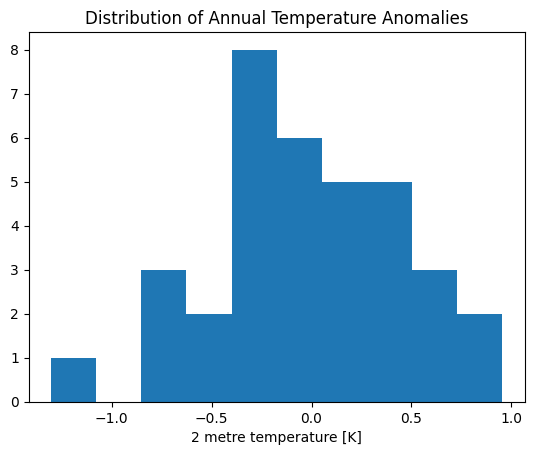

In [52]:
anomaly.plot.hist(bins=10)
plt.title("Distribution of Annual Temperature Anomalies")
plt.show()

In [53]:
anomaly.to_series().sort_values(ascending=False).head(5)

len(anomaly[anomaly > 0.5])

len(anomaly[anomaly < -0.5])

early.mean().values
Late.mean().values

array(0.18522644, dtype=float32)

In [54]:
print("Early mean:", early.mean().values)
print("Late mean :", Late.mean().values)

Early mean: -0.19612373
Late mean : 0.18522644


Comparison of annual temperature anomalies between 1990–2006 and 2007–2024 indicates a warming shift of approximately 0.38°C. The later period exhibits predominantly positive anomalies, consistent with the observed long-term warming trend over Punjab.


In [55]:
monthly_clim = punjab_ts.groupby("valid_time.month").mean()

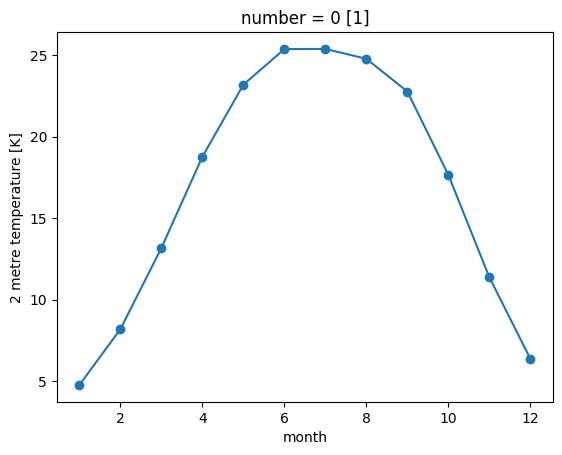

In [56]:
monthly_clim.plot(marker="o")

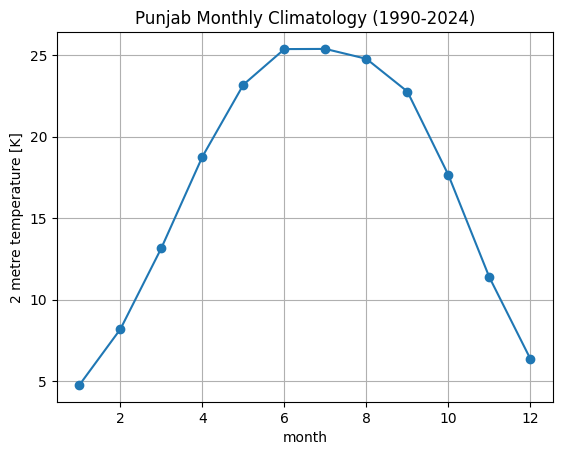

In [57]:
monthly_clim.plot(marker="o")
plt.grid(True)
plt.title("Punjab Monthly Climatology (1990-2024)")
plt.show()

In [58]:
#monthly climatology
monthly_clim = punjab_ts.groupby("valid_time.month").mean()
monthly_clim

<xarray.DataArray 't2m' (month: 12)> Size: 48B
array([ 4.761378 ,  8.190469 , 13.173031 , 18.776405 , 23.195217 ,
       25.377861 , 25.388422 , 24.781689 , 22.77182  , 17.651546 ,
       11.370602 ,  6.3617496], dtype=float32)
Coordinates:
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
    number   int64 8B ...
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      725
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

In [59]:
monthly_clim.shape

(12,)

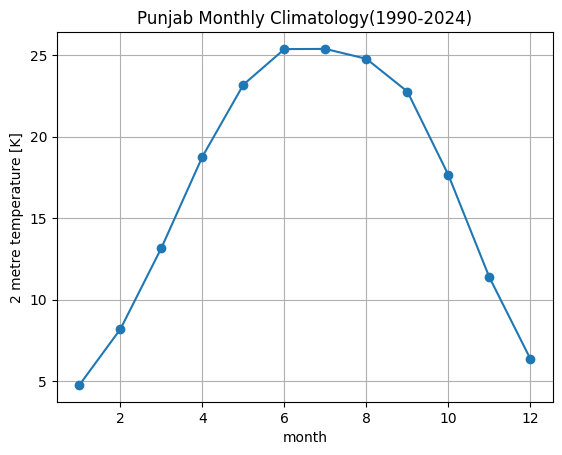

In [60]:
#plot
monthly_clim.plot(marker="o")
plt.grid(True)
plt.title("Punjab Monthly Climatology(1990-2024)")
plt.show()

In [61]:
print(monthly_clim.idxmax().values)
print(monthly_clim.max().values)

print(monthly_clim.idxmin().values)
print(monthly_clim.min().values)

7.0
25.388422
1.0
4.761378


In [62]:
summer = punjab_ts.sel(
    valid_time = punjab_ts.valid_time.dt.month.isin([4,5,6])

)
summer

<xarray.DataArray 't2m' (valid_time: 110)> Size: 440B
array([17.715216, 23.6053  , 25.999878, 16.480846, 21.904303, 24.655945,
       17.14191 , 21.352982, 25.196312, 18.262634, 23.780592, 25.544992,
       16.613518, 22.950932, 25.891983, 17.100441, 23.415186, 26.40184 ,
       18.490582, 21.828596, 23.776144, 16.668217, 20.389875, 23.949839,
       19.028502, 23.782427, 25.191935, 20.124763, 23.357311, 25.005455,
       19.88595 , 25.152414, 25.686312, 18.50303 , 24.09156 , 24.822401,
       19.77008 , 24.411222, 25.68178 , 19.27386 , 21.936665, 25.952114,
       20.353676, 23.441422, 24.699116, 17.931612, 21.7134  , 25.862865,
       19.19292 , 24.928282, 24.914284, 21.146896, 23.978262, 26.052055,
       18.401638, 22.762995, 25.025558, 18.615084, 23.096455, 25.31594 ,
       21.499271, 24.157778, 24.623838, 17.566126, 24.23772 , 25.18886 ,
       18.010921, 23.192247, 26.113256, 18.342667, 23.698896, 25.44938 ,
       17.537338, 22.064386, 26.291407, 18.080355, 23.09142 , 24.076216,
       19.608238, 24.34361 , 26.659025, 20.2138  , 24.051224, 24.82512 ,
       19.61405 , 23.239325, 25.57052 , 19.790844, 22.301376, 25.464584,
       17.895779, 22.507586, 25.23937 , 17.876572, 22.005049, 25.056194,
       22.34993 , 24.884089, 26.042604, 17.735975, 20.567373, 24.38513 ,
       18.038774, 24.557468, 26.726986, 20.915264, 23.938356, 26.26375 ,
       18.949774, 23.504913], dtype=float32)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 880B 1990-04-01 ... 2026-05-01
    expver      (valid_time) <U4 2kB ...
    number      int64 8B ...
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      725
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

In [63]:
#Summer climatology
summer_mean = summer.mean()
summer_mean


<xarray.DataArray 't2m' ()> Size: 4B
array(22.423208, dtype=float32)
Coordinates:
    number   int64 8B ...
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      725
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

In [64]:
summer_90s = summer.sel(
    valid_time=slice("1990","1999")
)

summer_20s = summer.sel(
    valid_time=slice("2020","2024")
)

print("1990s:", summer_90s.mean().values)
print("2020s:", summer_20s.mean().values)

1990s: 21.853613
2020s: 22.39126


In [65]:
print(monthly_clim.idxmax().values)
print(monthly_clim.max().values)

print("1990s:", summer_90s.mean().values)
print("2020s:", summer_20s.mean().values)

7.0
25.388422
1990s: 21.853613
2020s: 22.39126


Average summer temperatures in Punjab have increased by approximately 0.54°C between the 1990s and the 2020s.Annual shift ≈ 0.38°C
Summer shift ≈ 0.54°C

In [66]:
#Monthly Warming
clim_90s = punjab_ts.sel(
    valid_time = slice("1990","1999")
).groupby("valid_time.month").mean()


clim_20s = punjab_ts.sel(
    valid_time = slice("2020","2024")
).groupby("valid_time.month").mean()

In [67]:
monthly_change = clim_20s-clim_90s
monthly_change

<xarray.DataArray 't2m' (month: 12)> Size: 48B
array([-0.34327602,  1.207128  ,  1.8328333 ,  1.0167446 ,  0.26755905,
        0.32862473,  0.71422577,  0.974205  ,  1.3046818 ,  1.7383518 ,
        0.5937586 , -0.13436985], dtype=float32)
Coordinates:
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
    number   int64 8B 0
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      725
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

In [68]:
print("Month:", monthly_change.idxmax().values)
print("Warming:", monthly_change.max().values)

Month: 3.0
Warming: 1.8328333


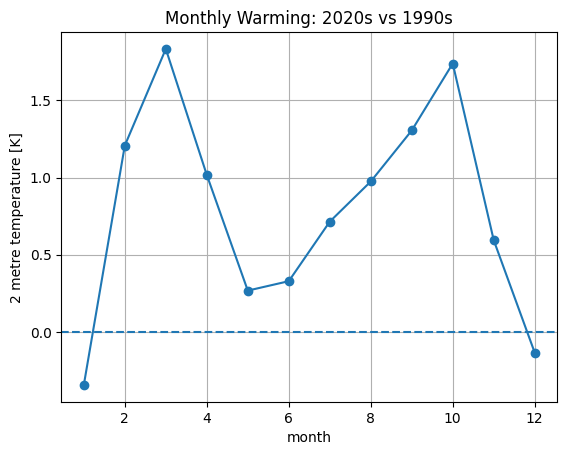

In [69]:
monthly_change.plot(marker="o")
plt.axhline(0, linestyle="--")
plt.grid(True)
plt.title("Monthly Warming: 2020s vs 1990s")
plt.show()

In [70]:
monthly_change.values

array([-0.34327602,  1.207128  ,  1.8328333 ,  1.0167446 ,  0.26755905,
        0.32862473,  0.71422577,  0.974205  ,  1.3046818 ,  1.7383518 ,
        0.5937586 , -0.13436985], dtype=float32)

In [71]:
months = ["Jan","Feb","Mar","Apr","May","Jun",
          "Jul","Aug","Sep","Oct","Nov","Dec"]

import pandas as pd

warming_df = pd.DataFrame({
    "Month": months,
    "Warming_C": monthly_change.values
})

warming_df

,Month,Warming_C
0,Jan,-0.343276
1,Feb,1.207128
2,Mar,1.832833
3,Apr,1.016745
4,May,0.267559
5,Jun,0.328625
6,Jul,0.714226
7,Aug,0.974205
8,Sep,1.304682
9,Oct,1.738352


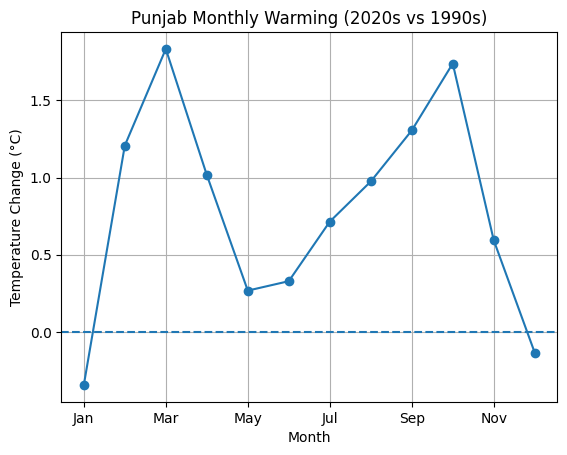

In [72]:
warming_df.plot(
    x="Month",
    y="Warming_C",
    marker="o",
    legend=False
)

plt.axhline(0, linestyle="--")
plt.ylabel("Temperature Change (°C)")
plt.title("Punjab Monthly Warming (2020s vs 1990s)")
plt.grid(True)
plt.show()

In [73]:
print(monthly_change.idxmax().values)
print(monthly_change.max().values)

3.0
1.8328333


In [74]:
spring = monthly_change.sel(month=[2,3,4])
summer = monthly_change.sel(month=[5,6,7])
monsoon = monthly_change.sel(month=[8,9,10])
winter = monthly_change.sel(month=[11,12,1])

In [75]:
print("Spring :", spring.mean().values)
print("Summer :", summer.mean().values)
print("Monsoon:", monsoon.mean().values)
print("Winter :", winter.mean().values)

Spring : 1.3522353
Summer : 0.4368032
Monsoon: 1.3390795
Winter : 0.038704235


In [76]:
seasonal = {
    "Spring": float(spring.mean()),
    "Summer": float(summer.mean()),
    "Monsoon": float(monsoon.mean()),
    "Winter": float(winter.mean())
}

seasonal

{'Spring': 1.3522353172302246,
 'Summer': 0.4368031919002533,
 'Monsoon': 1.33907949924469,
 'Winter': 0.03870423510670662}

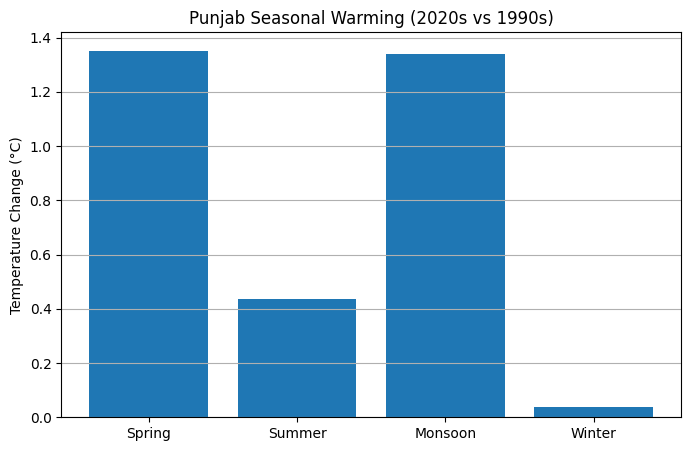

In [77]:
import matplotlib.pyplot as plt

seasons = ["Spring", "Summer", "Monsoon", "Winter"]
warming = [1.352, 0.437, 1.339, 0.039]

plt.figure(figsize=(8,5))

plt.bar(seasons, warming)

plt.ylabel("Temperature Change (°C)")
plt.title("Punjab Seasonal Warming (2020s vs 1990s)")

plt.grid(axis="y")

plt.show()

In [78]:
print(spring.values)

[1.207128  1.8328333 1.0167446]


In [79]:
seasons = ["Spring", "Summer", "Monsoon", "Winter"]

warming = [1.352, 0.437, 1.339, 0.039]

In [80]:
plt.figure(figsize=(8,5))

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<BarContainer object of 4 artists>

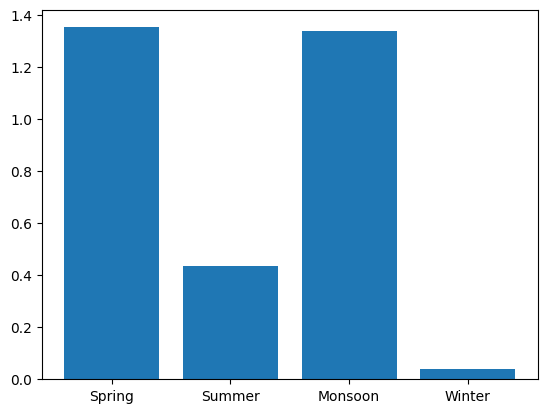

In [81]:
plt.bar(seasons, warming)

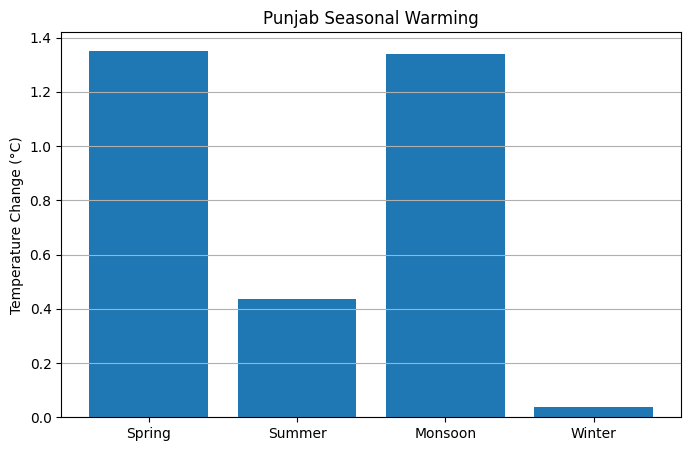

In [82]:
seasons = ["Spring", "Summer", "Monsoon", "Winter"]

warming = [
    float(spring.mean()),
    float(summer.mean()),
    float(monsoon.mean()),
    float(winter.mean())
]

plt.figure(figsize=(8,5))
plt.bar(seasons, warming)

plt.ylabel("Temperature Change (°C)")
plt.title("Punjab Seasonal Warming")

plt.grid(axis="y")

plt.show()

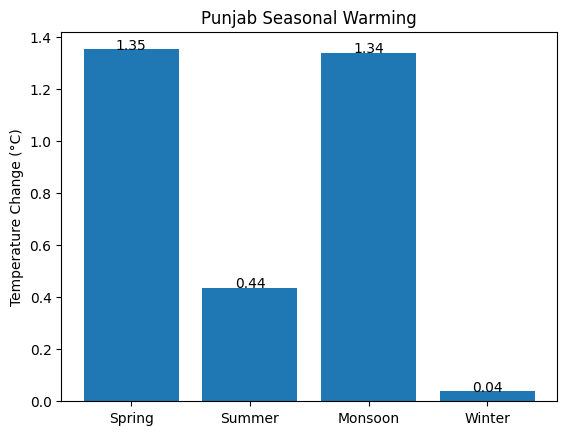

In [83]:
bars = plt.bar(seasons, warming)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha='center'
    )

plt.ylabel("Temperature Change (°C)")
plt.title("Punjab Seasonal Warming")
plt.show()

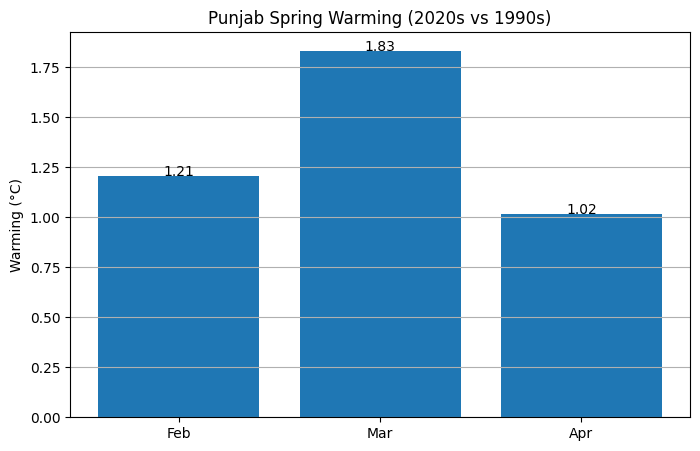

In [84]:
import matplotlib.pyplot as plt

months = ["Feb", "Mar", "Apr"]
warming = [1.207128, 1.8328333, 1.0167446]

plt.figure(figsize=(8,5))

bars = plt.bar(months, warming)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha="center"
    )

plt.ylabel("Warming (°C)")
plt.title("Punjab Spring Warming (2020s vs 1990s)")
plt.grid(axis="y")

plt.show()

In [85]:
march = punjab_ts.sel(
    valid_time = punjab_ts.valid_time.dt.month==3
)

march

<xarray.DataArray 't2m' (valid_time: 37)> Size: 148B
array([10.74118 , 12.347552, 11.737003, 10.627577, 13.886401, 11.816964,
       13.684301, 12.069647, 11.32287 , 13.350223, 11.721693, 12.79598 ,
       13.696292, 12.570296, 15.929935, 13.385513, 12.669116, 12.124926,
       15.20257 , 13.608265, 16.06224 , 13.295006, 12.783972, 13.340322,
       11.869938, 11.935812, 13.833859, 13.438823, 14.600388, 11.790563,
       11.864277, 14.779914, 16.302893, 13.800349, 13.20859 , 13.676621,
       15.530251], dtype=float32)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 296B 1990-03-01 ... 2026-03-01
    expver      (valid_time) <U4 592B ...
    number      int64 8B ...
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      725
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

In [86]:
march.shape

(37,)

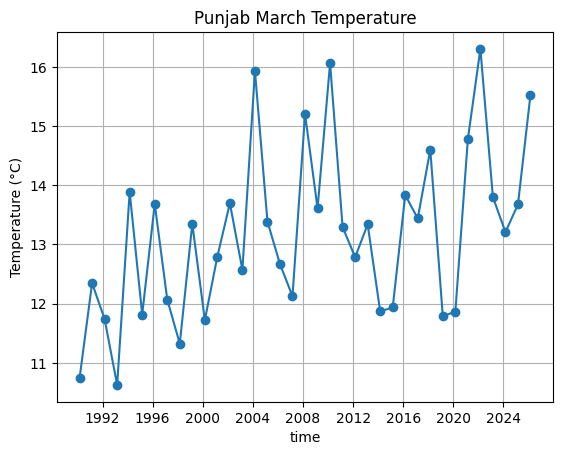

In [87]:
#march time series
march.plot(marker="o")
plt.title("Punjab March Temperature")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.show()

In [88]:
#mmarch trend callculation
import numpy as np
years = march.valid_time.dt.year.values
slope,intercept = np.polyfit(
    year,
    march.values,
    1
)

print("March trend (°C/year):", slope)
print("March trend (°C/decade):", slope*10)


March trend (°C/year): 0.061671017356933464
March trend (°C/decade): 0.6167101735693347


In [89]:
print("Warmest March:")
print(march.idxmax().values)
print(march.max().values)

print("Coldest March:")
print(march.idxmin().values)
print(march.min().values)

Warmest March:
2022-03-01T00:00:00.000000000
16.302893
Coldest March:
1993-03-01T00:00:00.000000000
10.627577


In [90]:
march.shape

slope*10

march.max().values

march.idxmax().values

np.datetime64('2022-03-01T00:00:00.000000000')

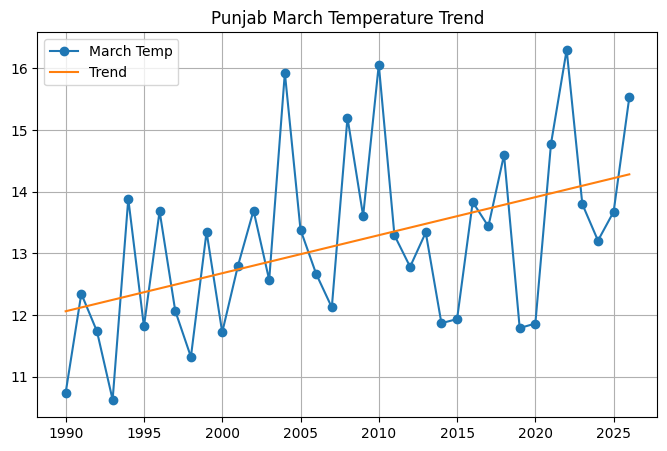

In [91]:
import numpy as np
import matplotlib.pyplot as plt

years = march.valid_time.dt.year.values

slope, intercept = np.polyfit(
    years,
    march.values,
    1
)

trend = slope * years + intercept

plt.figure(figsize=(8,5))

plt.plot(years, march.values, marker="o", label="March Temp")

plt.plot(years, trend, label="Trend")

plt.grid(True)
plt.legend()

plt.title("Punjab March Temperature Trend")

plt.show()

In [92]:
march_90s = march.sel(
    valid_time=slice("1990","1999")
)

march_20s = march.sel(
    valid_time=slice("2020","2024")
)

print("1990s:", march_90s.mean().values)
print("2020s:", march_20s.mean().values)

1990s: 12.158372
2020s: 13.991205


In [93]:
march.max().values

march.min().values

array(10.627577, dtype=float32)

In [94]:
print("Warmest March:", march.max().values)
print("Warmest March Year:", march.idxmax().values)

print("Coldest March:", march.min().values)
print("Coldest March Year:", march.idxmin().values)

march_90s = march.sel(valid_time=slice("1990","1999"))
march_20s = march.sel(valid_time=slice("2020","2024"))

print("1990s March Mean:", march_90s.mean().values)
print("2020s March Mean:", march_20s.mean().values)

Warmest March: 16.302893
Warmest March Year: 2022-03-01T00:00:00.000000000
Coldest March: 10.627577
Coldest March Year: 1993-03-01T00:00:00.000000000
1990s March Mean: 12.158372
2020s March Mean: 13.991205


March temperatures over Punjab exhibit a strong warming signal. Mean March temperature increased from approximately 12.16°C during the 1990s to 13.99°C during the 2020s, representing an increase of about 1.83°C. Trend analysis indicates a March warming rate of approximately 0.62°C per decade, substantially higher than the annual mean warming rate of 0.26°C per decade.


In [95]:
march_mean = march.mean()
print(march.values)

[10.74118  12.347552 11.737003 10.627577 13.886401 11.816964 13.684301
 12.069647 11.32287  13.350223 11.721693 12.79598  13.696292 12.570296
 15.929935 13.385513 12.669116 12.124926 15.20257  13.608265 16.06224
 13.295006 12.783972 13.340322 11.869938 11.935812 13.833859 13.438823
 14.600388 11.790563 11.864277 14.779914 16.302893 13.800349 13.20859
 13.676621 15.530251]


In [96]:
march_anomaly = march-march_mean
march_anomaly

<xarray.DataArray 't2m' (valid_time: 37)> Size: 148B
array([-2.4318504 , -0.82547855, -1.4360275 , -2.545454  ,  0.7133703 ,
       -1.3560667 ,  0.5112705 , -1.103384  , -1.8501606 ,  0.17719173,
       -1.4513378 , -0.3770504 ,  0.5232611 , -0.60273457,  2.7569046 ,
        0.21248245, -0.50391483, -1.0481052 ,  2.029539  ,  0.43523407,
        2.8892097 ,  0.12197495, -0.38905907,  0.16729069, -1.303093  ,
       -1.2372189 ,  0.6608286 ,  0.2657919 ,  1.4273567 , -1.3824682 ,
       -1.308754  ,  1.606883  ,  3.1298618 ,  0.6273184 ,  0.0355587 ,
        0.5035906 ,  2.3572197 ], dtype=float32)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 296B 1990-03-01 ... 2026-03-01
    expver      (valid_time) <U4 592B ...
    number      int64 8B 0
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      725
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

In [97]:
warm_marches = march_anomaly[march_anomaly>1]
print(len(warm_marches))
warm_marches

7


<xarray.DataArray 't2m' (valid_time: 7)> Size: 28B
array([2.7569046, 2.029539 , 2.8892097, 1.4273567, 1.606883 , 3.1298618,
       2.3572197], dtype=float32)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 56B 2004-03-01 ... 2026-03-01
    expver      (valid_time) <U4 112B ...
    number      int64 8B 0
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      725
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

In [98]:
cool_marches = march_anomaly[march_anomaly<-1]
print(len(cool_marches))
cool_marches

12


<xarray.DataArray 't2m' (valid_time: 12)> Size: 48B
array([-2.4318504, -1.4360275, -2.545454 , -1.3560667, -1.103384 ,
       -1.8501606, -1.4513378, -1.0481052, -1.303093 , -1.2372189,
       -1.3824682, -1.308754 ], dtype=float32)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 96B 1990-03-01 ... 2020-03-01
    expver      (valid_time) <U4 192B ...
    number      int64 8B 0
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      725
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

In [99]:
march_early = march_anomaly.sel(
    valid_time=slice("1990","2006")
)

march_late = march_anomaly.sel(
    valid_time=slice("2007","2024")
)

print("Early:", march_early.mean().values)
print("Late :", march_late.mean().values)

Early: -0.5640576
Late : 0.3737861


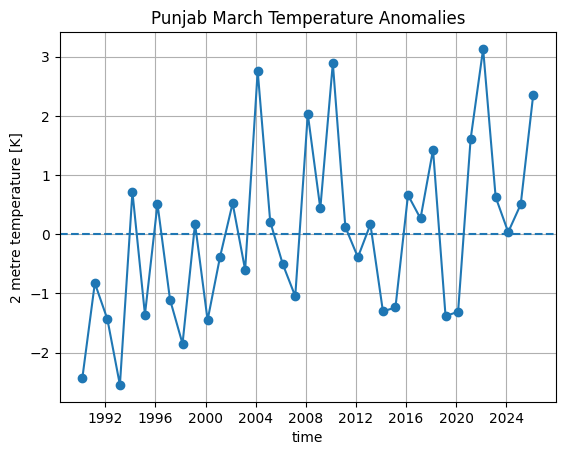

In [100]:
march_anomaly.plot(marker="o")

plt.axhline(0, linestyle="--")

plt.title("Punjab March Temperature Anomalies")
plt.grid(True)

plt.show()

In [101]:
len(warm_marches)

len(cool_marches)

march_early.mean().values

march_late.mean().values

array(0.3737861, dtype=float32)

In [102]:
print("Warm Marches:", len(warm_marches))

print("Cool Marches:", len(cool_marches))

print("Early Mean:", march_early.mean().values)

print("Late Mean:", march_late.mean().values)

Warm Marches: 7
Cool Marches: 12
Early Mean: -0.5640576
Late Mean: 0.3737861


March temperatures over Punjab show a clear warming shift. Mean March anomalies changed from -0.56°C during 1990–2006 to +0.37°C during 2007–2024, representing an increase of approximately 0.94°C. This indicates that recent March conditions are substantially warmer than the historical baseline.


In [103]:
march_after_2010 = march_anomaly.sel(
    valid_time=slice("2010","2024")
)

warm_after_2010 = (march_after_2010 > 0).sum()

total_after_2010 = len(march_after_2010)

print("Warm Marches:", warm_after_2010.values)
print("Total Marches:", total_after_2010)

print(
    "Percent:",
    (warm_after_2010.values / total_after_2010) * 100
)

Warm Marches: 10
Total Marches: 15
Percent: 66.66666666666666


In [104]:
#spring heat index
spring_ts = punjab_ts.sel(
    valid_time=punjab_ts.valid_time.dt.month.isin([2,3,4])
)

spring_ts

<xarray.DataArray 't2m' (valid_time: 111)> Size: 444B
array([ 7.5066495, 10.74118  , 17.715216 ,  7.3537655, 12.347552 ,
       16.480846 ,  6.191514 , 11.737003 , 17.14191  ,  9.369543 ,
       10.627577 , 18.262634 ,  6.8622117, 13.886401 , 16.613518 ,
        7.5908546, 11.816964 , 17.100441 ,  8.110158 , 13.684301 ,
       18.490582 ,  6.721875 , 12.069647 , 16.668217 ,  7.782578 ,
       11.32287  , 19.028502 ,  8.709751 , 13.350223 , 20.124763 ,
        5.5397944, 11.721693 , 19.88595  ,  8.375895 , 12.79598  ,
       18.50303  ,  7.6232476, 13.696292 , 19.77008  ,  7.9369974,
       12.570296 , 19.27386  ,  8.689127 , 15.929935 , 20.353676 ,
        7.1136303, 13.385513 , 17.931612 , 11.944995 , 12.669116 ,
       19.19292  ,  8.463231 , 12.124926 , 21.146896 ,  6.6461287,
       15.20257  , 18.401638 ,  9.129275 , 13.608265 , 18.615084 ,
        8.893599 , 16.06224  , 21.499271 ,  8.130982 , 13.295006 ,
       17.566126 ,  6.7555895, 12.783972 , 18.010921 ,  7.548447 ,
       13.340322 , 18.342667 ,  6.8481016, 11.869938 , 17.537338 ,
        9.078758 , 11.935812 , 18.080355 ,  8.582413 , 13.833859 ,
       19.608238 ,  9.5645895, 13.438823 , 20.2138   ,  9.22285  ,
       14.600388 , 19.61405  ,  7.2364626, 11.790563 , 19.790844 ,
        8.203103 , 11.864277 , 17.895779 , 10.042398 , 14.779914 ,
       17.876572 ,  7.854864 , 16.302893 , 22.34993  , 10.505903 ,
       13.800349 , 17.735975 ,  7.52882  , 13.20859  , 18.038774 ,
        9.15873  , 13.676621 , 20.915264 , 10.230525 , 15.530251 ,
       18.949774 ], dtype=float32)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 888B 1990-02-01 ... 2026-04-01
    expver      (valid_time) <U4 2kB ...
    number      int64 8B ...
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      725
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

In [105]:
#annual spring mean
spring_yealy = spring_ts.groupby(

    "valid_time.year"
).mean()

spring_yealy



<xarray.DataArray 't2m' (year: 37)> Size: 148B
array([11.987681 , 12.060721 , 11.690143 , 12.753251 , 12.454043 ,
       12.169419 , 13.428348 , 11.819913 , 12.711316 , 14.06158  ,
       12.38248  , 13.224968 , 13.696541 , 13.260385 , 14.990913 ,
       12.810252 , 14.602344 , 13.911685 , 13.416779 , 13.784207 ,
       15.485036 , 12.997371 , 12.516828 , 13.077146 , 12.085126 ,
       13.031642 , 14.00817  , 14.405738 , 14.479095 , 12.93929  ,
       12.654386 , 14.232961 , 15.5025625, 14.014076 , 12.925395 ,
       14.583538 , 14.903516 ], dtype=float32)
Coordinates:
  * year     (year) int64 296B 1990 1991 1992 1993 1994 ... 2023 2024 2025 2026
    number   int64 8B ...
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      725
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

In [106]:
spring_yealy.shape

(37,)

In [107]:
#Calculate Spring Trend
years = spring_yealy.year.values

slope,intercept = np.polyfit(
    years,
    spring_yealy.values,
    1
)
print("Spring trend(°C/decade):",slope*10)


Spring trend(°C/decade): 0.5232952171278616


In [108]:
spring_yealy.shape

print("Spring trend:", slope*10)

Spring trend: 0.5232952171278616


Punjab is warming, but the warming is concentrated in the late winter / spring season rather than being uniform throughout the year.

Temperature trends over Punjab indicate seasonally asymmetric warming. While annual mean temperature increased at approximately 0.26°C per decade, spring temperatures (February-April) increased at approximately 0.52°C per decade. March exhibited the strongest warming signal at approximately 0.62°C per decade, suggesting that pre-monsoon warming is occurring faster than the annual average.


In [109]:
spring_yealy.mean().values

array(13.379968, dtype=float32)

In [110]:
spring_yealy.std().values

array(1.0239314, dtype=float32)

In [111]:
spring_mean = spring_yealy.mean()
spring_std = spring_yealy.std()
thresold = spring_mean + spring_std
print(thresold.values)

14.403899


In [112]:
hot_spring = spring_yealy[
    spring_yealy>thresold
]

print(hot_spring)

<xarray.DataArray 't2m' (year: 8)> Size: 32B
array([14.990913 , 14.602344 , 15.485036 , 14.405738 , 14.479095 ,
       15.5025625, 14.583538 , 14.903516 ], dtype=float32)
Coordinates:
  * year     (year) int64 64B 2004 2006 2010 2017 2018 2022 2025 2026
    number   int64 8B ...
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      725
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0


In [113]:
print(hot_spring.year.values)

[2004 2006 2010 2017 2018 2022 2025 2026]


Since most of the hot spring are after 2010 which mean climate warming, it mesns increasing extreme warm seasons

In [114]:
print("Mean:", spring_mean.values)

print("Std:", spring_std.values)



Mean: 13.379968
Std: 1.0239314


In [115]:
thresold = 13.37+1.02
thresold

14.389999999999999

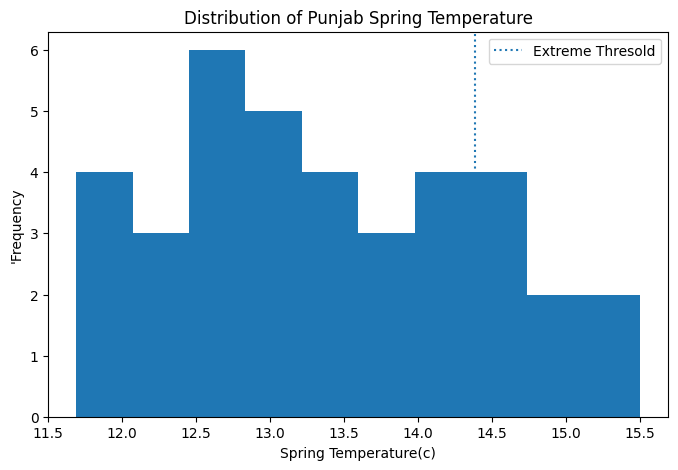

In [116]:
#plotting 
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(spring_yealy.values,bins=10)

plt.axvline(
    thresold,
    linestyle=":",
    label = "Extreme Thresold"
)

plt.xlabel("Spring Temperature(c)")
plt.ylabel("'Frequency")

plt.title("Distribution of Punjab Spring Temperature")
plt.legend()
plt.show()

In [117]:
#COLD SPRINGS
cold_threshold = spring_mean - spring_std


cold_springs = spring_yealy[
    spring_yealy<cold_threshold
]
print(cold_springs.year.values)
print(len(cold_springs))

[1990 1991 1992 1995 1997 2014]
6


8 hot springs out of 37 years mean 8/37= 0.216 mean 21.6 % 
37/8 = 4.6 which mean extreme warm spring occurs roughly once every 4-5 years


In [118]:
hot_count = len(hot_spring)
total_years = len(spring_yealy)

probablitiy = hot_count/total_years

return_period = total_years/hot_count
print("Probablity:",probablitiy)
print("Return Period:", return_period)

Probablity: 0.21621621621621623
Return Period: 4.625


In [119]:
spring_yealy.sortby(spring_yealy)

<xarray.DataArray 't2m' (year: 37)> Size: 148B
array([11.690143 , 11.819913 , 11.987681 , 12.060721 , 12.085126 ,
       12.169419 , 12.38248  , 12.454043 , 12.516828 , 12.654386 ,
       12.711316 , 12.753251 , 12.810252 , 12.925395 , 12.93929  ,
       12.997371 , 13.031642 , 13.077146 , 13.224968 , 13.260385 ,
       13.416779 , 13.428348 , 13.696541 , 13.784207 , 13.911685 ,
       14.00817  , 14.014076 , 14.06158  , 14.232961 , 14.405738 ,
       14.479095 , 14.583538 , 14.602344 , 14.903516 , 14.990913 ,
       15.485036 , 15.5025625], dtype=float32)
Coordinates:
  * year     (year) int64 296B 1992 1997 1990 1991 2014 ... 2026 2004 2010 2022
    number   int64 8B ...
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      725
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

In [120]:
spring_yealy.sortby(spring_yealy)[-5:]

<xarray.DataArray 't2m' (year: 5)> Size: 20B
array([14.602344 , 14.903516 , 14.990913 , 15.485036 , 15.5025625],
      dtype=float32)
Coordinates:
  * year     (year) int64 40B 2006 2026 2004 2010 2022
    number   int64 8B ...
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      725
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

In [121]:
spring_yealy.sortby(spring_yealy)[-5:].year.values

array([2006, 2026, 2004, 2010, 2022])

NameError: name 'threshold' is not defined

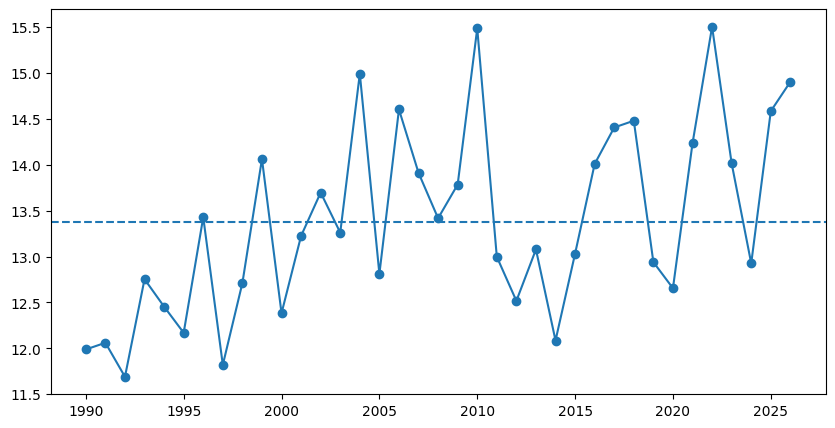

In [122]:
import matplotlib.pyplot as plt

years = spring_yealy.year.values

plt.figure(figsize=(10,5))

plt.plot(
    years,
    spring_yealy.values,
    marker="o"
)

plt.axhline(
    spring_mean,
    linestyle="--",
    label="Mean"
)

plt.axhline(
    threshold,
    linestyle=":",
    label="Extreme Thresold"
)

plt.legend()
plt.grid(True)

plt.title("Punjab Spring Temperature (1990-2026)")

plt.xlabel("Year")
plt.ylabel("Temperature (°C)")

plt.show()

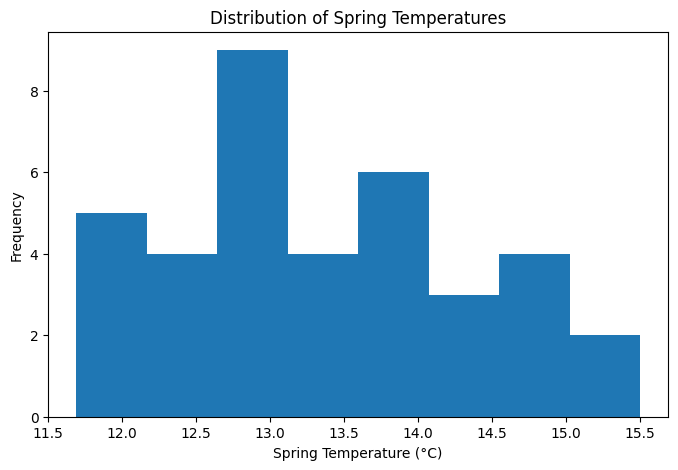

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    spring_yealy.values,
    bins=8
)

plt.xlabel("Spring Temperature (°C)")
plt.ylabel("Frequency")

plt.title("Distribution of Spring Temperatures")

plt.show()

In [ ]:
spring_90s = spring_yealy.sel(year=slice(1990,1999))

spring_20s = spring_yealy.sel(year=slice(2020,2026))

print("1990s Mean:", spring_90s.mean().values)
print("2020s Mean:", spring_20s.mean().values)

print("1990s Std:", spring_90s.std().values)
print("2020s Std:", spring_20s.std().values)

1990s Mean: 12.513642
2020s Mean: 14.116633
1990s Std: 0.7136182
2020s Std: 0.951634


Comparison of spring temperatures between the 1990s and 2020s indicates a substantial warming signal over Punjab. Mean spring temperature increased by approximately 1.6°C, while interannual variability also increased. The combination of higher temperatures and greater variability suggests an increasing likelihood of extreme warm spring seasons, which may have implications for agricultural productivity and climate-related risk.


In [ ]:
spring_mean = spring_yealy.mean()

spring_std = spring_yealy.std()

threshold = spring_mean + spring_std

print(threshold.values)

14.403899


In [ ]:
hot_90s = (spring_90s > threshold).sum()

hot_20s = (spring_20s > threshold).sum()

print("1990s hot springs:", hot_90s.values)
print("2020s hot springs:", hot_20s.values)

print("1990s %:", (hot_90s.values/len(spring_90s))*100)
print("2020s %:", (hot_20s.values/len(spring_20s))*100)

1990s hot springs: 0
2020s hot springs: 3
1990s %: 0.0
2020s %: 42.857142857142854


In [ ]:
#create loop
import numpy as np
for month in range (1,13):
    m=punjab_ts.sel(
        valid_time = punjab_ts.valid_time.dt.month == month
    )

    years = m.valid_time.dt.year.values

    slope,intercept = np.polyfit(
        years,
        m.values,
        1
    )

    print(
        month,
        round(slope*10,3)
    )

1 -0.058
2 0.487
3 0.617
4 0.466
5 0.142
6 0.129
7 0.21
8 0.239
9 0.409
10 0.503
11 0.144
12 -0.047


In [ ]:
monthly_trends = [
-0.058,
0.487,
0.617,
0.466,
0.142,
0.129,
0.210,
0.239,
0.409,
0.503,
0.144,
-0.047
]

import numpy as np

print("Mean trend:", np.mean(monthly_trends))
print("Std trend :", np.std(monthly_trends))

Mean trend: 0.27008333333333334
Std trend : 0.21297474745977643


In [ ]:
march_z = (0.617 - np.mean(monthly_trends)) / np.std(monthly_trends)

print(march_z)

1.6289098628098488


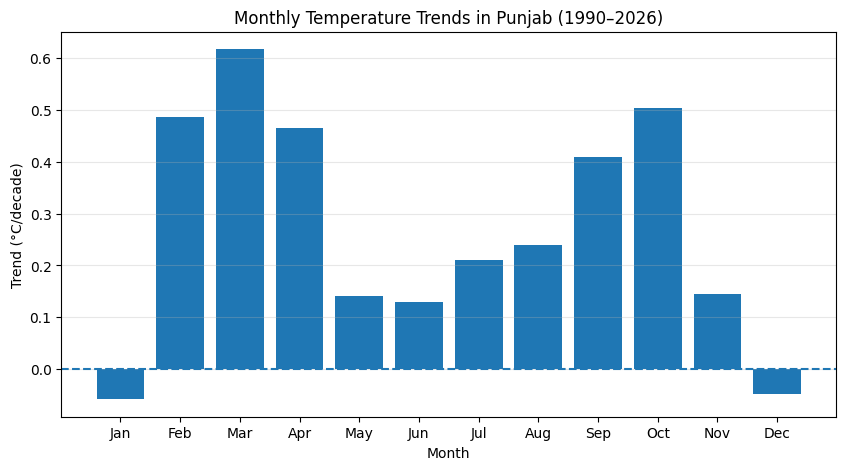

In [ ]:
import matplotlib.pyplot as plt

months = [
    "Jan","Feb","Mar","Apr",
    "May","Jun","Jul","Aug",
    "Sep","Oct","Nov","Dec"
]

trends = [
    -0.058,
    0.487,
    0.617,
    0.466,
    0.142,
    0.129,
    0.210,
    0.239,
    0.409,
    0.503,
    0.144,
    -0.047
]

plt.figure(figsize=(10,5))

plt.bar(months, trends)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.ylabel("Trend (°C/decade)")
plt.xlabel("Month")
plt.title("Monthly Temperature Trends in Punjab (1990–2026)")

plt.grid(axis='y', alpha=0.3)

plt.show()

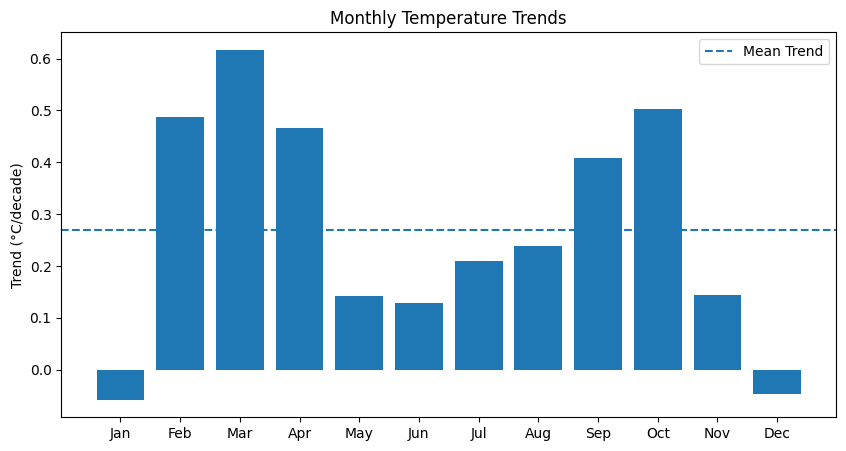

In [ ]:
plt.figure(figsize=(10,5))

bars = plt.bar(months, trends)

plt.axhline(
    y=np.mean(trends),
    linestyle='--',
    label='Mean Trend'
)

plt.ylabel("Trend (°C/decade)")
plt.title("Monthly Temperature Trends")

plt.legend()

plt.show()

In [ ]:
march = ds['t2m'].sel(
    valid_time=ds.valid_time.dt.month == 3
)

In [ ]:
print(march.shape)

(37, 29, 25)


In [ ]:
import xarray as xr 
import numpy as np

years = march.valid_time.dt.year


trend_map = xr.apply_ufunc(
    lambda y : np.polyfit(year,y,1)[0]*10,
    march,
    input_core_dims = [["valid_time"]],
    vectorize=True,
    output_dtypes=[float]
)

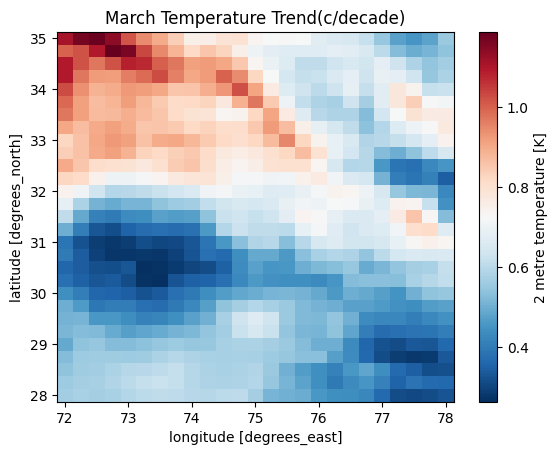

In [ ]:
plt.Figure(figsize=(8,6))


trend_map.plot(
    cmap="RdBu_r"
)

plt.title(
    "March Temperature Trend(c/decade)"

)

plt.show()

In [124]:
print(ds['t2m'].dims)

('valid_time', 'latitude', 'longitude')


In [127]:
years = march.valid_time.dt.year.astype(float)
print(years[:5].values)

[1990. 1991. 1992. 1993. 1994.]


In [135]:
import numpy as np
import xarray as xr

trend_map = xr.apply_ufunc(
    lambda y: np.polyfit(years, y, 1)[0] * 10,
    march,
    input_core_dims=[["valid_time"]],
    vectorize=True,
    output_dtypes=[float]
)

In [136]:
print(trend_map.shape)
print(trend_map.dims)

()
()


In [137]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

trend_map.plot(
    cmap="RdBu_r"
)

plt.title(
    "March Temperature Trend (c/decade)"
)

plt.show()

TypeError: No numeric data to plot.

<Figure size 1000x600 with 0 Axes>

In [143]:
print(ds)
print(ds.dims)
print(ds.coords)
print(ds.data_vars)

<xarray.Dataset> Size: 1MB
Dimensions:     (valid_time: 437, latitude: 29, longitude: 25)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 3kB 1990-01-01 ... 2026-05-01
    expver      (valid_time) <U4 7kB ...
  * latitude    (latitude) float64 232B 35.0 34.75 34.5 ... 28.5 28.25 28.0
  * longitude   (longitude) float64 200B 72.0 72.25 72.5 ... 77.5 77.75 78.0
    number      int64 8B ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 1MB 275.0 ... 305.4
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-06-09T17:43 GRIB to CDM+CF via cfgrib-0.9.1...
FrozenMappingWarningOnValuesAccess({'valid_time': 437, 'latitude': 29, 'longitude': 25})
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 3kB 19

In [144]:
t2m = ds["t2m"] - 273.15

In [145]:
print(t2m.dims)
print(t2m.shape)

('valid_time', 'latitude', 'longitude')
(437, 29, 25)


In [146]:
march = t2m.sel(
    valid_time=t2m.valid_time.dt.month == 3
)

print(march.shape)

(37, 29, 25)


In [147]:
import numpy as np
import xarray as xr

years = march.valid_time.dt.year.astype(float)

trend_map = xr.apply_ufunc(
    lambda y: np.polyfit(years, y, 1)[0] * 10,
    march,
    input_core_dims=[["valid_time"]],
    vectorize=True,
    output_dtypes=[float]
)

In [148]:
print(trend_map.shape)
print(trend_map.dims)

(29, 25)
('latitude', 'longitude')


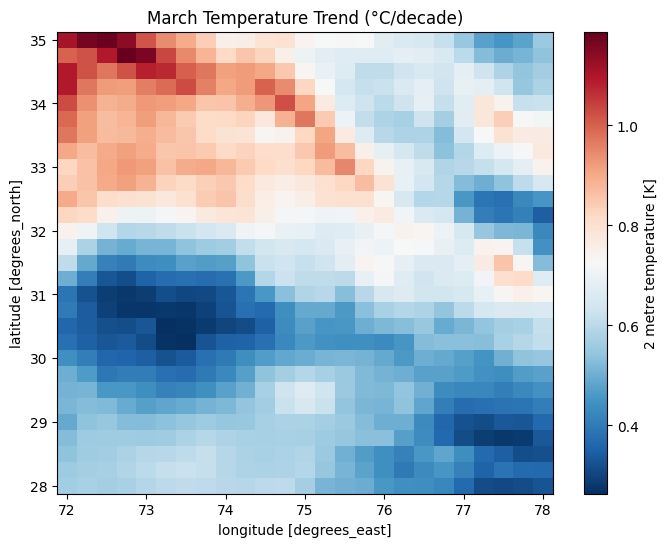

In [149]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

trend_map.plot(
    cmap="RdBu_r"
)

plt.title(
    "March Temperature Trend (°C/decade)"
)

plt.show()

In [150]:
print(float(trend_map.max()))
print(float(trend_map.min()))

1.1875001736419737
0.2633868127481851


Spatial analysis of March temperature trends indicates widespread warming across the study region. All grid cells exhibit positive trends, ranging from approximately 0.26°C/decade to 1.19°C/decade. The results suggest that warming is spatially heterogeneous, with some locations experiencing substantially faster temperature increases than others.


In [151]:
max_loc = trend_map.where(
    trend_map == trend_map.max(),
    drop=True
)

print(max_loc)

<xarray.DataArray 't2m' (latitude: 1, longitude: 1)> Size: 8B
array([[1.18750017]])
Coordinates:
  * latitude   (latitude) float64 8B 34.75
  * longitude  (longitude) float64 8B 72.75
    number     int64 8B 0
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      725
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0


In [153]:
print(max_loc.latitude.values)
print(max_loc.longitude.values)

[34.75]
[72.75]


In [154]:
print(ds.latitude.min().values,
      ds.latitude.max().values)

print(ds.longitude.min().values,
      ds.longitude.max().values)

28.0 35.0
72.0 78.0


In [155]:
march = t2m.sel(
    valid_time=t2m.valid_time.dt.month == 3
)

In [156]:
march_90s = march.sel(
    valid_time=slice("1990","1999")
)

march_20s = march.sel(
    valid_time=slice("2020","2026")
)

In [157]:
mean_90s = march_90s.mean(dim="valid_time")

mean_20s = march_20s.mean(dim="valid_time")

In [158]:
change_map = mean_20s - mean_90s

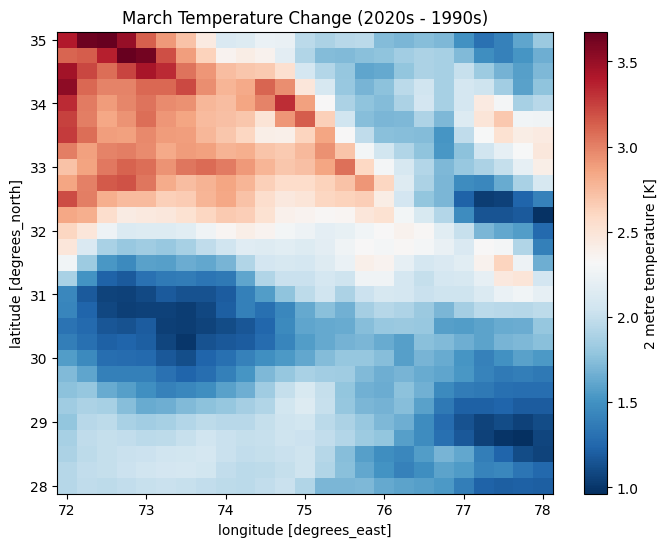

In [159]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

change_map.plot(
    cmap="RdBu_r"
)

plt.title(
    "March Temperature Change (2020s - 1990s)"
)

plt.show()

In [160]:
print(float(change_map.max()))
print(float(change_map.min()))
print(float(change_map.mean()))

3.674877166748047
0.9634380340576172
2.0077555179595947
